In [20]:
WDN_NAME = "Kadu"
BASE_DIR = f"old/data/{WDN_NAME}"
VIZ_DIR = f"old/viz/{WDN_NAME}"

In [21]:
import json
import os
import pickle
from pathlib import Path
import importlib.util

import networkx as nx
from PIL import Image

import algorithms.registry as registry

def _noop_register(_name):
    def decorator(func):
        return func
    return decorator

registry.REGISTRY.register = _noop_register


In [22]:
base_dir = Path(BASE_DIR)
data_dir = base_dir / "data_generator"

graph_path = data_dir / "graph_with_measurements.pickle"
artifacts_path = data_dir / "evaluation_artifacts.json"

with graph_path.open("rb") as f:
    G = pickle.load(f)
with artifacts_path.open("r", encoding="utf-8") as f:
    artifacts = json.load(f)

secondary_pipes = artifacts.get("secondary_pipes", [])
measurement_nodes = artifacts.get("measurement_nodes", [])

In [23]:
viz_path = Path("algorithms/5_visualization/visualize_network.py")
viz_spec = importlib.util.spec_from_file_location("viz_network", viz_path)
viz_module = importlib.util.module_from_spec(viz_spec)
viz_spec.loader.exec_module(viz_module)
visualize_network_3d = viz_module.visualize_network_3d

bp_path = Path("algorithms/9_visualize-evaluation/visualize_evaluation.py")
bp_spec = importlib.util.spec_from_file_location("viz_eval", bp_path)
bp_module = importlib.util.module_from_spec(bp_spec)
bp_spec.loader.exec_module(bp_module)
create_base_pressure_visualization = bp_module.create_base_pressure_visualization

In [24]:
def _to_2d_pos(pos):
    pos_2d = {}
    for node, coord in pos.items():
        if isinstance(coord, (list, tuple)) and len(coord) >= 2:
            pos_2d[node] = (float(coord[0]), float(coord[1]))
        else:
            pos_2d[node] = (0.0, 0.0)
    return pos_2d

G_bp = G.copy()
pos = nx.get_node_attributes(G_bp, "pos")
if pos:
    nx.set_node_attributes(G_bp, _to_2d_pos(pos), "pos")

Saved 3D plot to: old/viz/Kadu/network_3d.png
Saved base pressure plot to: old/viz/Kadu/base_pressure.png


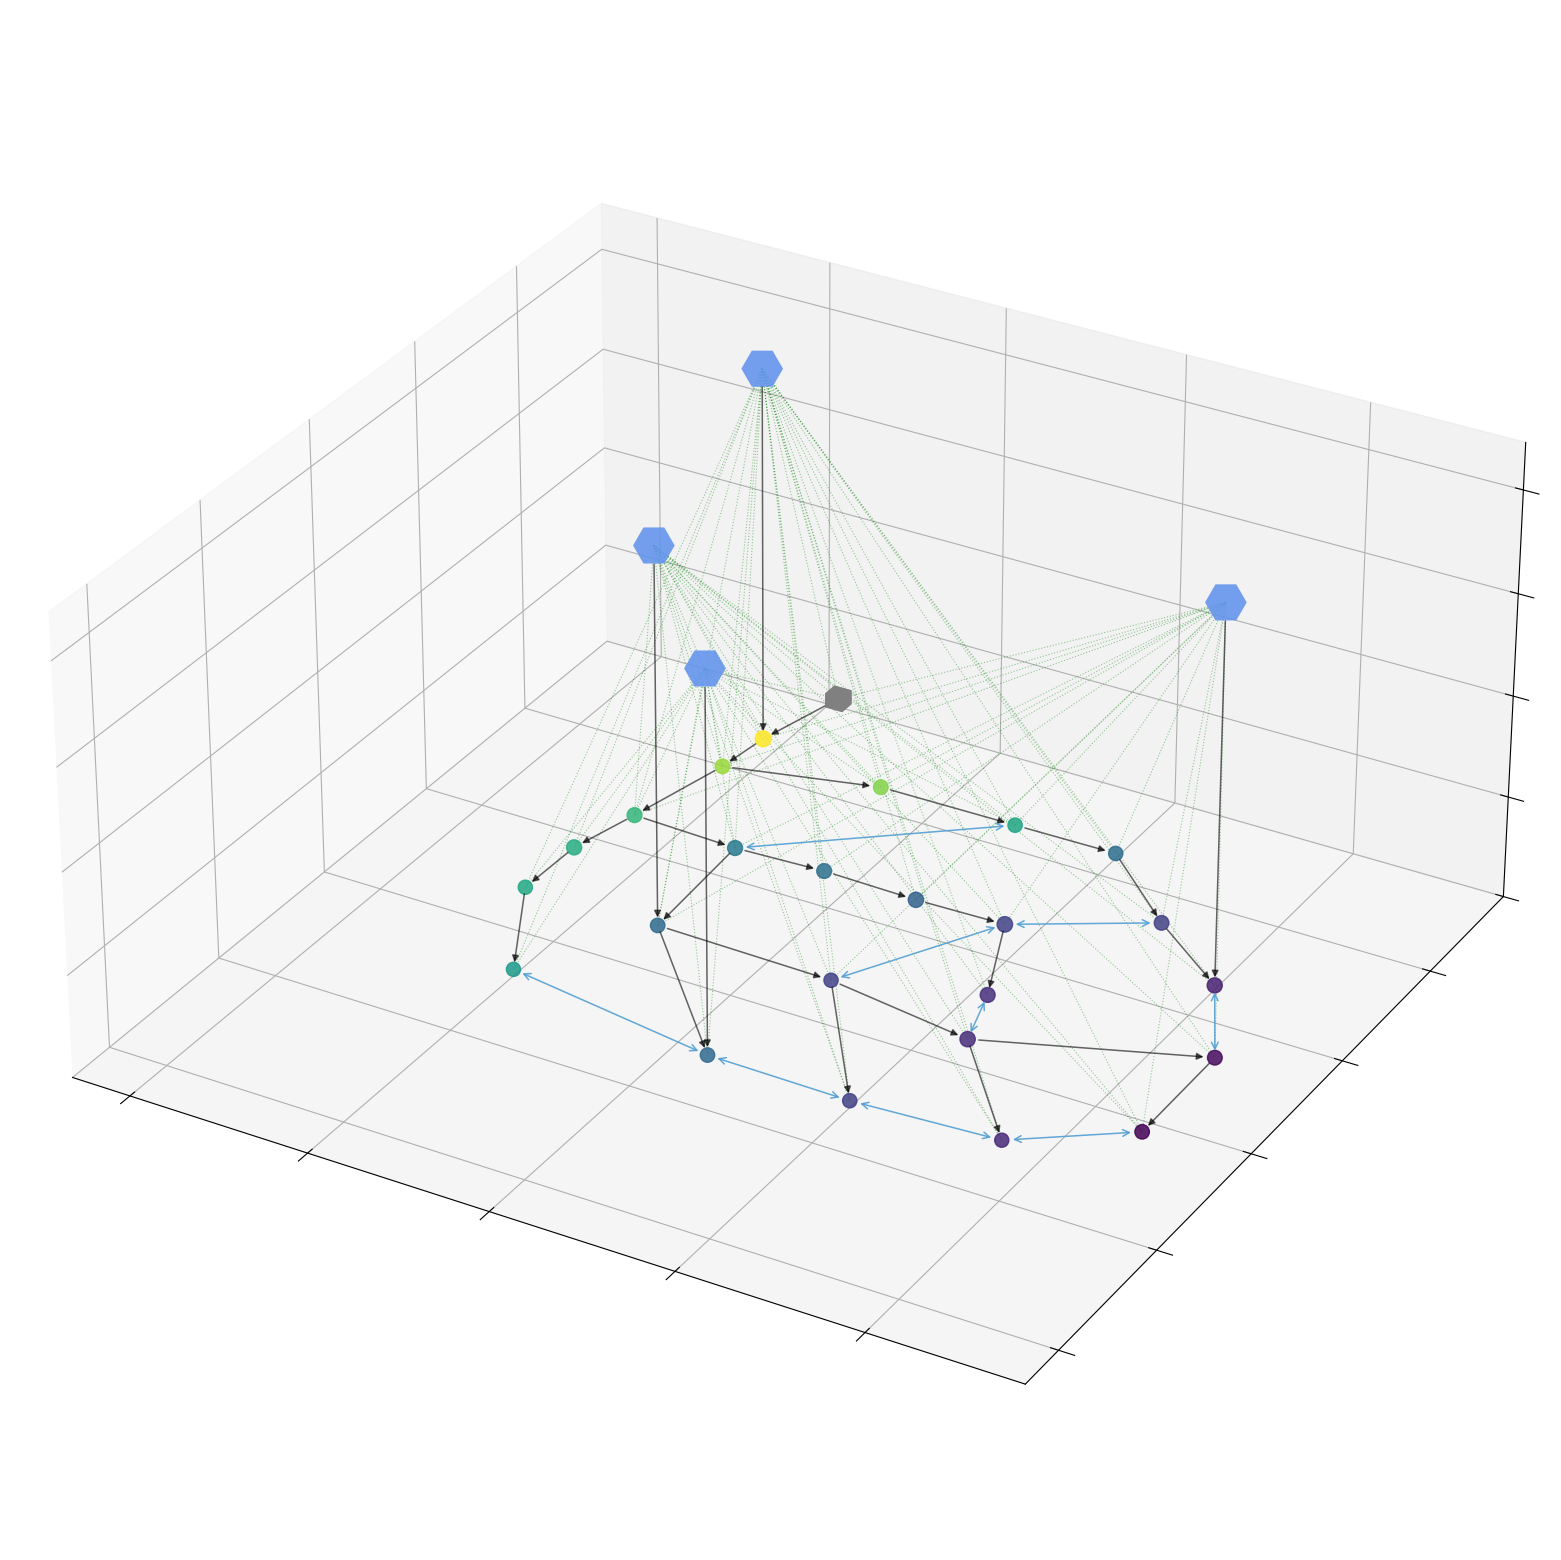

In [25]:
def _crop_whitespace(path, threshold=245):
    image = Image.open(path).convert("RGB")
    width, height = image.size
    pixels = image.load()

    min_x, min_y = width, height
    max_x, max_y = -1, -1

    for y in range(height):
        for x in range(width):
            r, g, b = pixels[x, y]
            if r < threshold or g < threshold or b < threshold:
                if x < min_x:
                    min_x = x
                if y < min_y:
                    min_y = y
                if x > max_x:
                    max_x = x
                if y > max_y:
                    max_y = y

    if max_x < min_x or max_y < min_y:
        return

    cropped = image.crop((min_x, min_y, max_x + 1, max_y + 1))
    cropped.save(path)


output_dir = Path(VIZ_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

fig_3d = visualize_network_3d(G, secondary_pipes=secondary_pipes, measurement_nodes=measurement_nodes)
for ax in fig_3d.axes:
    ax.set_title("")
path_3d = output_dir / "network_3d.png"
fig_3d.savefig(path_3d, dpi=200)

G_bp_simple = nx.DiGraph(G_bp)
for node in list(G_bp_simple.nodes()):
    if str(node).startswith("meas_"):
        G_bp_simple.remove_node(node)

edges_to_drop = []
for u, v, data in G_bp_simple.edges(data=True):
    if data.get("type") in {"Measurement_Connection", "Measurement_Self_Connection"}:
        edges_to_drop.append((u, v))
for u, v in edges_to_drop:
    if G_bp_simple.has_edge(u, v):
        G_bp_simple.remove_edge(u, v)

bp_image = create_base_pressure_visualization(
    G_bp_simple,
    node_masks=[],
    exclude_indices=[],
    secondary_pipes=secondary_pipes,
    measurement_nodes=measurement_nodes
)
path_bp = output_dir / "base_pressure.png"
bp_image.save(path_bp)

_crop_whitespace(path_3d)
_crop_whitespace(path_bp)

print(f"Saved 3D plot to: {path_3d}")
print(f"Saved base pressure plot to: {path_bp}")
